In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

sys.path.append("../..")

from src.visualization.clusterization import plot_clustering_report

In [2]:
data_dir = Path("../../data")

In [3]:
features_df = pd.read_csv(data_dir / "processed" / "features_mirrors.csv")

filtered_mirrors_ts_df = pd.read_csv(data_dir / "processed" / "filtered_mirrors_ts.csv")

In [4]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "mean",
    "std",
    "cv",
    "zero_ratio",
    "spike_ratio",
    "max_mean_ratio",
    "sign_changes",
    "slope",
    "autocorr_lag1",
    "height",
    "width",
    "weight",
]

df_encoded = pd.get_dummies(features_df, columns=["subj_name"], prefix="cat")

scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(df_encoded[feature_cols])

cat_cols = [c for c in df_encoded.columns if c.startswith("cat_")]
X = np.hstack([numeric_scaled, df_encoded[cat_cols].values])

# KMeans

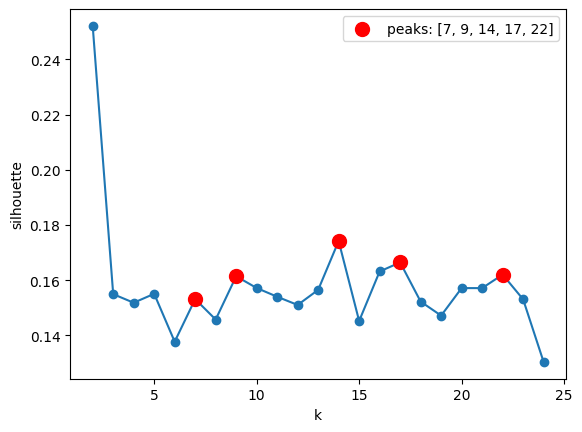

In [5]:
from scipy.signal import find_peaks
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
K_range = range(2, 25)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

scores_array = np.array(scores)
peaks_idx, properties = find_peaks(scores_array, prominence=0.005)

best_ks = [K_range[i] for i in peaks_idx]

plt.plot(K_range, scores, marker="o")
plt.scatter(
    [K_range[i] for i in peaks_idx],
    scores_array[peaks_idx],
    color="red",
    s=100,
    zorder=5,
    label=f"peaks: {best_ks}",
)
plt.xlabel("k")
plt.ylabel("silhouette")
plt.legend()

for k in best_ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    features_df[f"kmeans_k{k}"] = km.fit_predict(X)

In [6]:
from umap import UMAP

reducer = UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

/home/nikita/projects/microniches/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


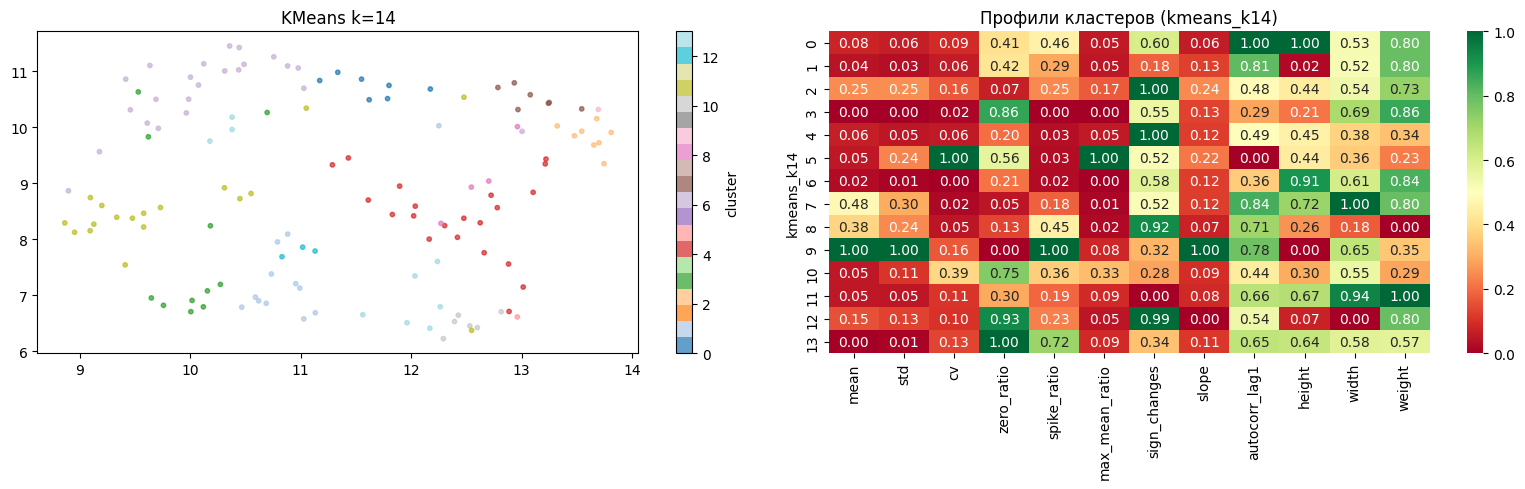

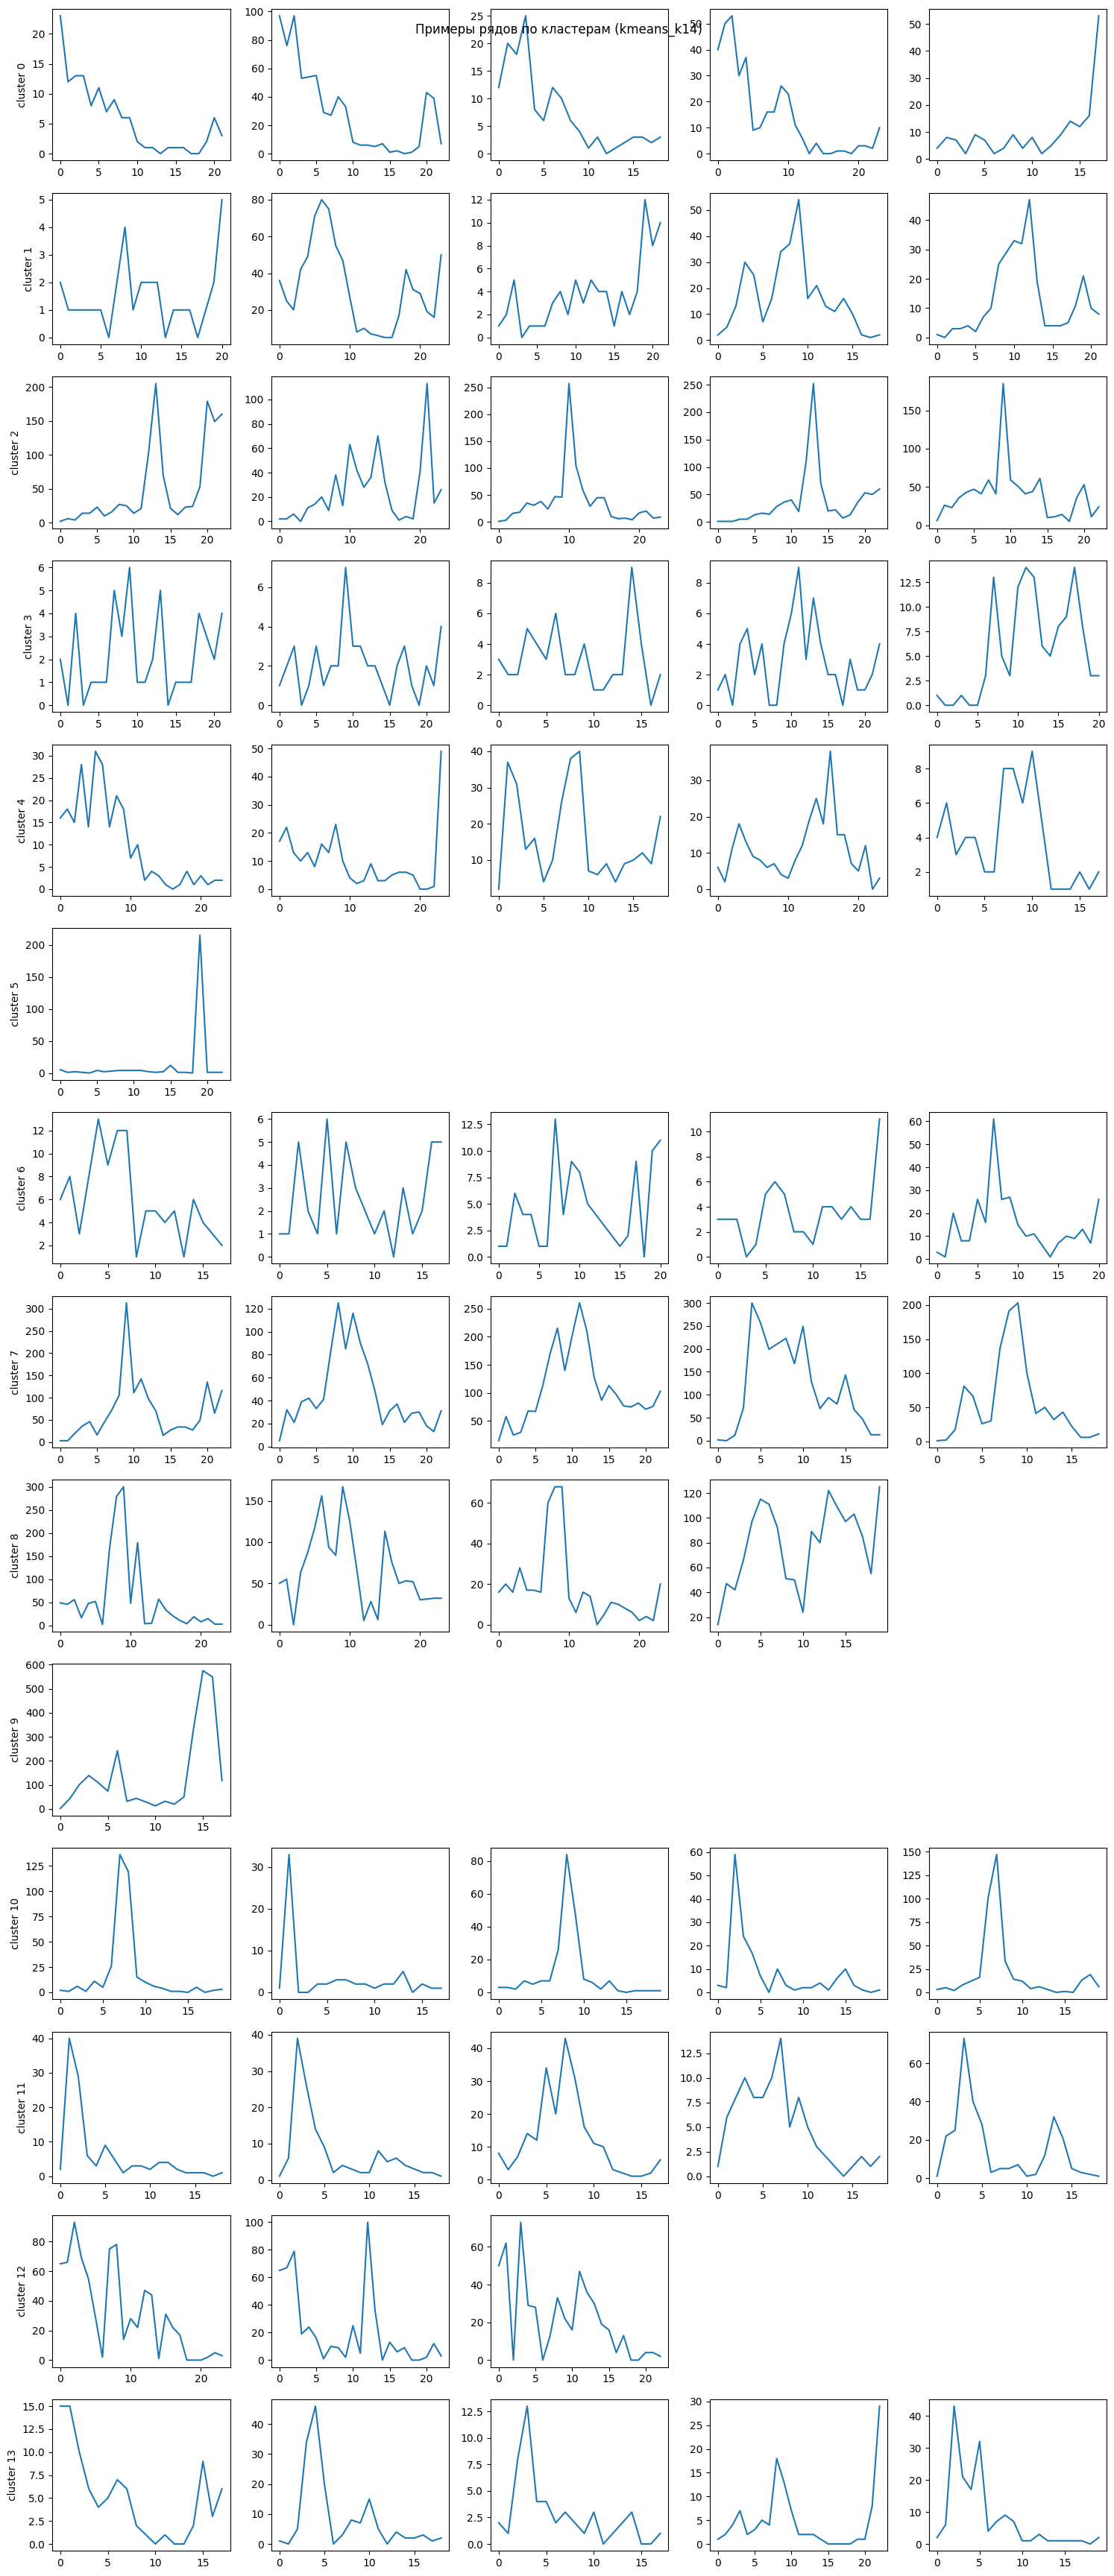

In [8]:
k = 14
plot_clustering_report(
    features_df,
    filtered_mirrors_ts_df,
    embedding,
    f"kmeans_k{k}",
    feature_cols,
    title=f"KMeans k={k}",
)
None

# HDBSCAN

In [9]:
from hdbscan import HDBSCAN

clusterer = HDBSCAN(min_cluster_size=30, min_samples=5)
features_df["hdbscan"] = clusterer.fit_predict(X)

n_clusters = features_df["hdbscan"].nunique() - 1
n_noise = (features_df["hdbscan"] == -1).sum()
print(f"Кластеров: {n_clusters}, шум: {n_noise} ({n_noise * 100 / len(features_df):.2f}%)")

Кластеров: 0, шум: 131 (100.00%)


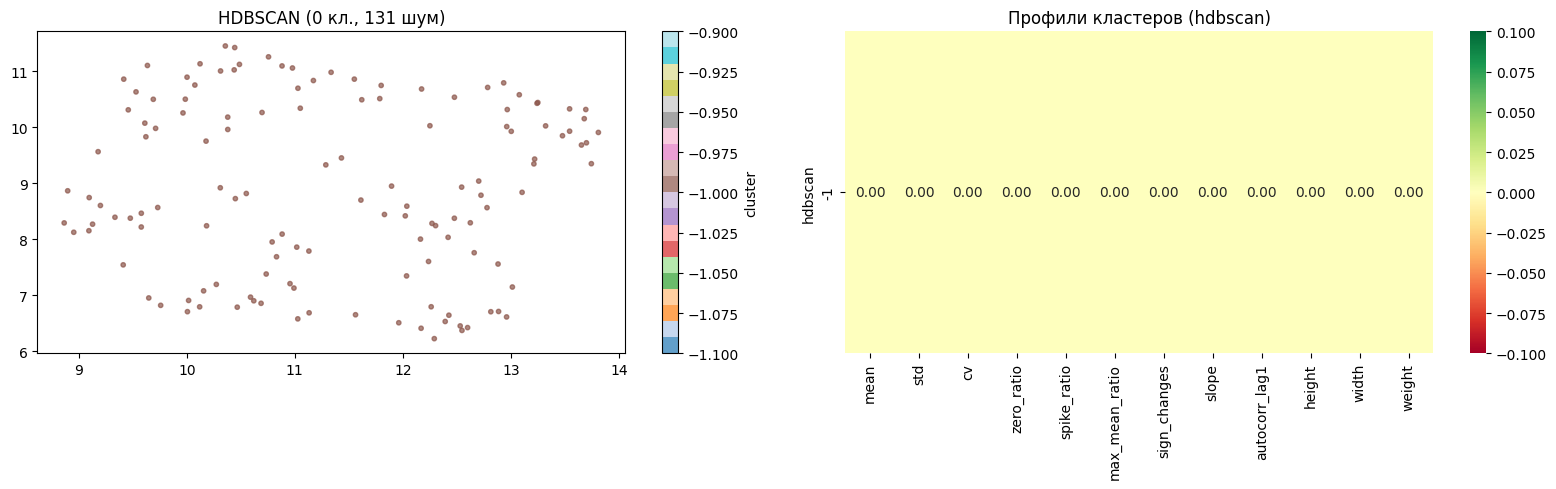

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>

In [10]:
plot_clustering_report(
    features_df,
    filtered_mirrors_ts_df,
    embedding,
    "hdbscan",
    feature_cols,
    title=f"HDBSCAN ({n_clusters} кл., {n_noise} шум)",
)

Кластеров: 0, шум: 131 (100.00%)


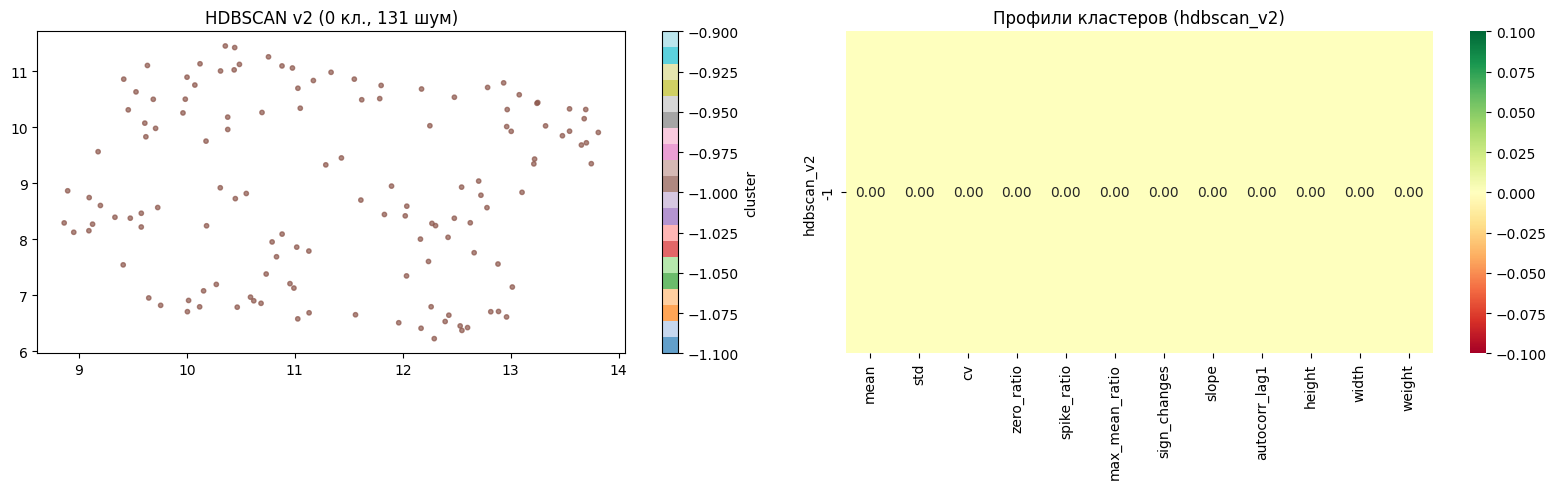

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1500x0 with 0 Axes>

In [11]:
from hdbscan import HDBSCAN

clusterer = HDBSCAN(min_cluster_size=15, min_samples=3, prediction_data=True)
features_df["hdbscan_v2"] = clusterer.fit_predict(X)

n_clusters = features_df["hdbscan_v2"].nunique() - 1
n_noise = (features_df["hdbscan_v2"] == -1).sum()
print(f"Кластеров: {n_clusters}, шум: {n_noise} ({n_noise * 100 / len(features_df):.2f}%)")

plot_clustering_report(
    features_df,
    filtered_mirrors_ts_df,
    embedding,
    "hdbscan_v2",
    feature_cols,
    title=f"HDBSCAN v2 ({n_clusters} кл., {n_noise} шум)",
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

core_mask = features_df["hdbscan_v2"] != -1
noise_mask = ~core_mask

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X[core_mask], features_df.loc[core_mask, "hdbscan_v2"])

features_df["cluster_final"] = features_df["hdbscan_v2"].copy()
features_df.loc[noise_mask, "cluster_final"] = knn.predict(X[noise_mask])

features_df["is_core"] = core_mask

print(f"Core points: {features_df['is_core'].sum()}")
print(f"Assigned noise: {(~features_df['is_core']).sum()}")
features_df["cluster_final"].value_counts().sort_index()

ValueError: Found array with 0 sample(s) (shape=(0, 15)) while a minimum of 1 is required by KNeighborsClassifier.

In [ ]:
features_df[["article", "cluster_final", "is_core"]].to_csv(
    data_dir / "processed" / "mirrors_clusters.csv", index=False
)